In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lagp.utils.generate_data import load_real_data, train_test_split, load_X_y_preprocessed, load_cv_splits
from lagp.utils.metrics import quantile_score
from lagp.models.model import model_gpboost, model_gpytorch
import os

In [2]:
dataset = "bike"
DIR = "../data/real_data"
n_splits = 5

In [3]:
X, y = load_X_y_preprocessed(dataset_name= dataset, dir = DIR)

In [4]:
folds = load_cv_splits(dataset_name= dataset, dir= DIR, n_splits= n_splits)

In [5]:
train_idx = folds[0]["train_idx"]
test_idx = folds[0]["test_idx"]
print(len(X))
print("train len", len(train_idx))
print("test len", len(test_idx))

17379
train len 13903
test len 3476


In [6]:
X_train = X.iloc[train_idx,:]
y_train = y.iloc[train_idx]
X_test = X.iloc[test_idx, :]
y_test = y.iloc[test_idx]

In [7]:
# settings
target_quantile = 0.9
approx = "asymmetric_laplace_constant_curvature_fisher_mode_finding"
delta_logl = 10
threshold_approx = 1000

In [8]:
# fit GPBoost
pred, elapsed_time = model_gpboost(
                quantile=target_quantile,
                train_X=X_train,
                train_y=y_train,
                test_X=X_test,
                test_y=y_test,
                approx=approx,
                delta_logl=delta_logl,
                n_vecchia= threshold_approx,
            )
print(f"Elapsed Time: {elapsed_time}")
latent_pred = pred["mu"]
qs_loss = quantile_score(y = y_test, preds=latent_pred, quantile=target_quantile)
print(f"Quantile Score: {qs_loss}")

[GPBoost] [Info] Starting nearest neighbor search for Vecchia approximation
[GPBoost] [Info] Nearest neighbors for Vecchia approximation found
[GPBoost] [Info] Using CC_LLS_MIN_DECREASE_LOG_LIKE_ = 10
[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 30, delta_mode_ = 93.157, delta_log_like_up_ = 11.6593, delta_log_like_down_ = 5.59359e+06
[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 26, delta_mode_ = 22.9792, delta_log_like_up_ = 10.0253, delta_log_like_down_ = 154231
[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 28, delta_mode_ = 28.0549, delta_log_like_up_ = 10.0559, delta_log_like_down_ = 103335
[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 28, delta_mode_ = 46.9455, delta_log_like_up_ = 10.0648, delta_log_like_down_ = 70717.6
[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 30, delta_mode_ = 70.4787, delta_log_like_up_ = 10.0651, delta_log_like_down_ = 60782.7
[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 31, delta_

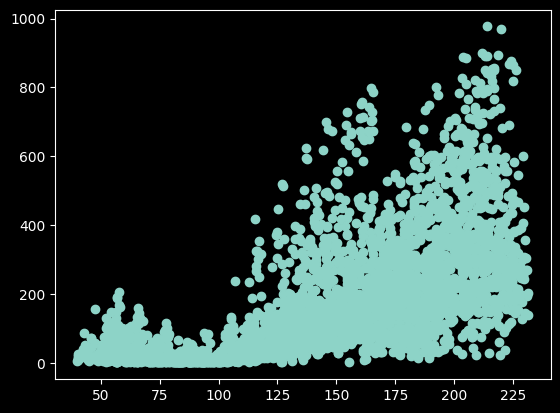

In [13]:
plt.scatter(latent_pred, y_test)

In [17]:
# fit GPytorch
n_epochs = 500
lr = 0.1
inducing_points = 500
pred, elapsed_time = model_gpytorch(
                quantile=target_quantile,
                train_X=X_train,
                train_y=y_train,
                test_X=X_test,
                test_y=y_test,
                epochs=n_epochs,
                lr = lr,
                inducing_threshold=threshold_approx,
                inducing_points=inducing_points
            )
latent_pred_vi = pred.mean.numpy()
print(f"Elapsed Time: {elapsed_time}")
qs_loss = quantile_score(y = y_test, preds=latent_pred_vi, quantile=target_quantile)
print(f"Quantile Score: {qs_loss}")

Epoch 0: Loss = 173.9289
Epoch 50: Loss = 31.2159
Epoch 100: Loss = 12.1216
Epoch 150: Loss = 11.6850
Epoch 200: Loss = 11.3031
Epoch 250: Loss = 10.9589
Epoch 300: Loss = 10.6550
Epoch 350: Loss = 10.3890
Epoch 400: Loss = 10.1501
Epoch 450: Loss = 9.9361
Elapsed Time: 491.2185626029968
Quantile Score: 27.787477801227457


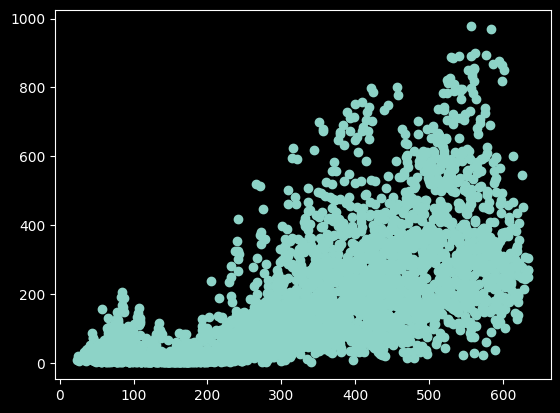

In [16]:
plt.scatter(latent_pred_vi, y_test)

In [10]:
# laod resutls
import pickle
path = "../results/realdata/realdata_results_python.pkl"

with open(path, "rb") as f:
    res = pickle.load(f)

In [11]:
res["results"]

{'bike': {0: {'gpboost_cc': {'quantile_loss': np.float64(12.733922375412778),
    'time': 3180.7781031131744},
   'gpytorch': {'quantile_loss': np.float64(149.76506236698637),
    'time': 3.3150734901428223}},
  1: {'gpboost_cc': {'quantile_loss': np.float64(11.580688315367535),
    'time': 5047.205927610397},
   'gpytorch': {'quantile_loss': np.float64(153.37608250343624),
    'time': 2.167426347732544}}},
 'power': {0: {'gpboost_cc': {'quantile_loss': np.float64(14301.746085614055),
    'time': 1882.5359756946564},
   'gpytorch': {'quantile_loss': np.float64(14302.328440805646),
    'time': 0.4536592960357666}},
  1: {'gpboost_cc': {'quantile_loss': np.float64(14233.704500275335),
    'time': 1896.8328557014465},
   'gpytorch': {'quantile_loss': np.float64(14234.321508597071),
    'time': 0.4139432907104492}}}}